In [2]:
%cd ../
%load_ext autoreload
%autoreload 2

/home/christian/bachelor-project


In [8]:
# BiLSTM training for 12-hour wind vector forecasting

# This notebook trains `BiLSTMModel` on 10-min measurements to forecast the next 12 hours (72 steps)
# of u/v vector components per station.

import os
from omegaconf import OmegaConf
from loguru import logger
import pandas as pd

from src.database.database_service import DatabaseService
from src.weather_stations.weather_station_service import WeatherStationService
from src.measurements.measurement_service import MeasurementService
from src.model.variant.bilstm_model import BiLSTMModel
from src.model.variant.patch_tst_model import PatchTSTModel

In [4]:
# Load config and initialize services
cfg = OmegaConf.load("conf/config.yaml")

db = DatabaseService(cfg)
ws_service = WeatherStationService(cfg, db)
weather_stations = ws_service.load_from_database(only_relevant=True)

ms_service = MeasurementService(cfg, db, weather_stations)

logger.info(f"Loaded {len(weather_stations)} weather stations")


2025-09-20 00:03:34.754 | INFO     | src.weather_stations.weather_station_data_provider:load_from_database:236 - Loaded 32 weather stations from database
2025-09-20 00:03:34.767 | INFO     | __main__:<module>:10 - Loaded 32 weather stations


In [5]:
# Load measurements from DB
measurements_df = ms_service.load_all_measurements_from_database()
logger.info(f"Measurements: {len(measurements_df)} rows")


KeyboardInterrupt: 

In [5]:
measurements_df.to_parquet("data/measurements.parquet")

In [5]:
measurements_df = pd.read_parquet("data/measurements.parquet")

In [6]:
# Optional: downsample or filter timeframe for quicker training
end_date = pd.Timestamp('2025-04-01')
train_df = measurements_df[(measurements_df['record_date']<=end_date)].copy()

test_df = measurements_df[measurements_df['record_date']>end_date].copy()

train_df.head()

,air_pressure,air_temperature_2m,air_temperature_5cm,average_wind_direction,average_wind_speed,dew_point_temperature,id,precipitation_duration,precipitation_indicator,quality_level,record_date,relative_humidity,station_id,sum_precipitation_height
5000,1003.8,4.2,3.4,300.0,4.6,2.6,5001,9.0,1,3,2020-02-04 17:20:00,89.3,96,0.1
5001,1003.9,4.0,3.3,300.0,3.3,2.5,5002,5.0,1,3,2020-02-04 17:30:00,89.9,96,0.0
10000,997.6,6.6,6.0,190.0,5.6,3.9,10001,0.0,0,3,2020-03-10 10:40:00,83.1,96,0.0
10001,997.5,6.5,6.0,200.0,5.8,4.1,10002,0.0,0,3,2020-03-10 10:50:00,84.8,96,0.0
10002,997.6,6.3,5.8,200.0,6.1,4.3,10003,0.0,0,3,2020-03-10 11:00:00,87.1,96,0.0


In [ ]:
# Instantiate BiLSTM model



model = PatchTSTModel(
    history_steps=144,   # 24 hours of history (10-min resolution)
    horizon_steps=72,    # 12 hours forecast
    d_model=256,
    nhead=8,
    num_layers=4,
    dim_feedforward=512,
    patch_len=16,
    stride=8,
    dropout=0.1,
    batch_size=128,
    learning_rate=3e-4,
    num_epochs=5,
    val_split=0.2,
    early_stopping_patience=5,
    early_stopping_min_delta=1e-4,
    restore_best_weights=True
)
model


In [7]:
# Train model
model.train(train_df)


/home/christian/bachelor-project/src/model/variant/patch_tst_model.py:758: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(resample_group)
2025-09-19 12:18:15.012 | INFO     | src.model.variant.patch_tst_model:train:212 - PatchTST: train_sequences=7045406, val_sequences=1760808, stations=32, feature_dim=10, device=cuda
/home/christian/bachelor-project/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
2025-09-19 12:18:15.969 | INFO     | src.model.variant.patch_tst_model:train:258 - Epoch 1/5 starting (lr=3.000e-04)


KeyboardInterrupt: 

In [47]:
# Save model
save_dir = "models/new_model"
os.makedirs(save_dir, exist_ok=True)
model.save(save_dir)
logger.info(f"Saved BiLSTM model to {save_dir}")


2025-09-12 16:43:06.659 | INFO     | __main__:<module>:5 - Saved BiLSTM model to models/new_model


In [9]:
new_model = PatchTSTModel()

In [10]:
new_model.load('models/patch_tst')

/home/christian/bachelor-project/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [11]:
# Quick prediction demo for a subset (uses last 72 steps per station)
preds = new_model.predict(measurements_df)
preds.head()


/home/christian/bachelor-project/src/model/variant/patch_tst_model.py:765: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(resample_group)


,station_id,record_date,u_pred,v_pred,average_wind_speed_pred,average_wind_direction_pred
0,96.0,2025-09-18 12:30:00,0.973359,0.572982,1.129485,239.516205
1,96.0,2025-09-18 12:40:00,0.952170,0.575735,1.112699,238.840485
2,96.0,2025-09-18 12:50:00,0.936751,0.547472,1.085001,239.696381
3,96.0,2025-09-18 13:00:00,0.928724,0.550532,1.079636,239.341217
4,96.0,2025-09-18 13:10:00,0.933835,0.558940,1.088330,239.097687


In [15]:
evaluation = new_model.evaluate(test_df)


2025-09-13 11:52:27.897 | INFO     | src.model.variant.bilstm_model:evaluate:14 - Evaluation: samples=1112291, batch_size=64, batches=17380
2025-09-13 11:56:41.836 | INFO     | src.model.variant.bilstm_model:evaluate:63 - Evaluation metrics: mae_u=0.1071, rmse_u=0.2863, mae_v=0.0641, rmse_v=0.2913, mae_speed=0.0651, rmse_speed=0.1736, mae_direction_deg=6.35°


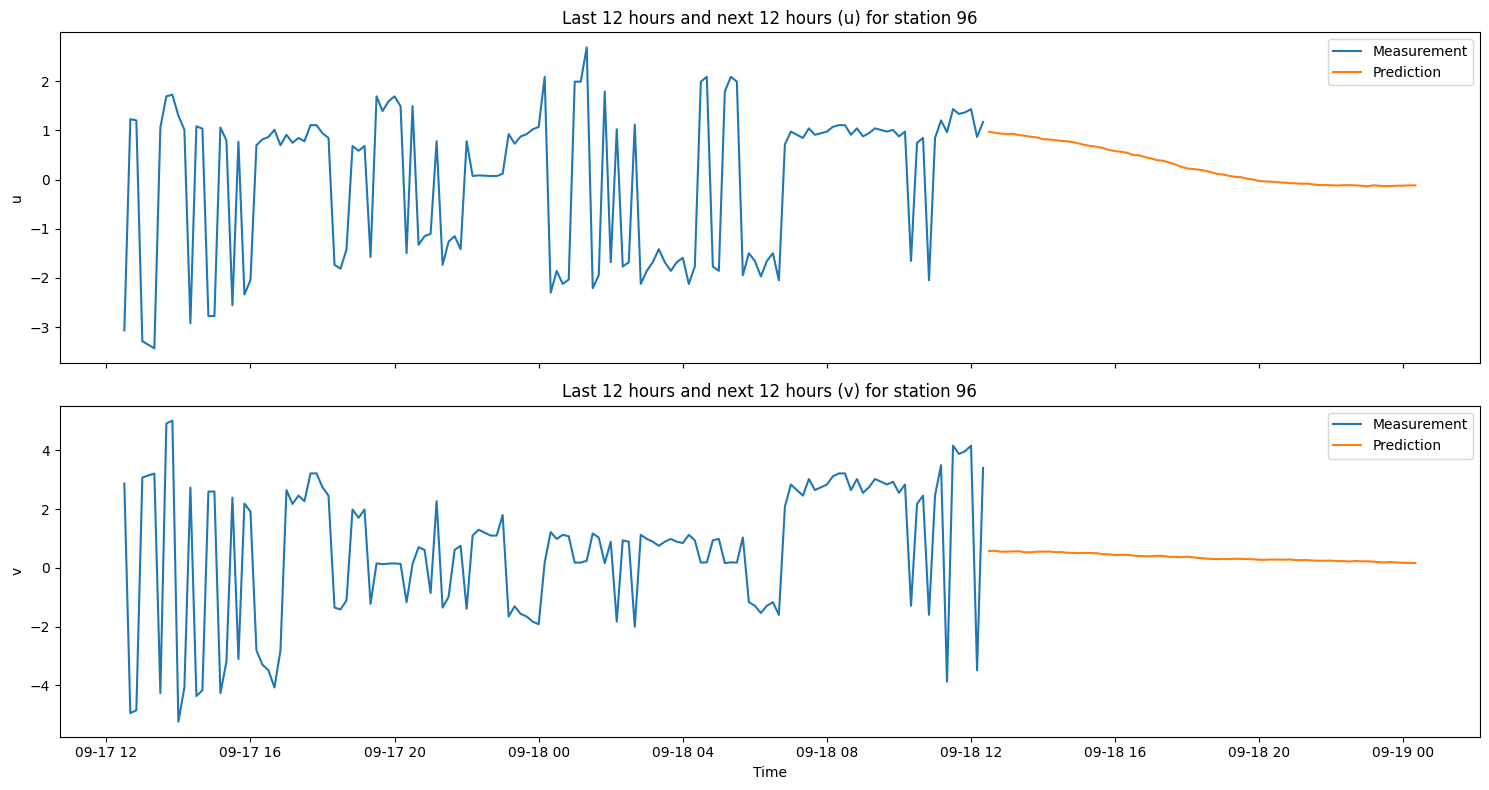

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Only use station_id = 96
station_id = 96

# Ensure record_date is datetime
test_df = test_df.copy()
test_df["record_date"] = pd.to_datetime(test_df["record_date"])
preds = preds.copy()
preds["record_date"] = pd.to_datetime(preds["record_date"])

# Filter for station_id = 96
test_df_96 = test_df[test_df["station_id"] == station_id]
preds_96 = preds[preds["station_id"] == station_id]

# Find the last timestamp in test_df_96
last_test_time = test_df_96["record_date"].max()
# Get the last 12 hours of measurements (10-min interval: 72 steps)
twelve_hours_ago = last_test_time - pd.Timedelta(hours=24)
test_last12 = test_df_96[test_df_96["record_date"] > twelve_hours_ago].sort_values("record_date")

# Calculate u and v for test_last12
test_last12 = test_last12.copy()
test_last12["u"] = test_last12["average_wind_speed"] * np.cos(test_last12["average_wind_direction"])
test_last12["v"] = test_last12["average_wind_speed"] * np.sin(test_last12["average_wind_direction"])

# For preds, get the predictions for station_id = 96, and for the 12 hours after last_test_time
preds_12h = preds_96[preds_96["record_date"] > last_test_time].sort_values("record_date").head(72)

# Concatenate for plotting
plot_df = pd.DataFrame({
    "record_date": pd.concat([test_last12["record_date"], preds_12h["record_date"]]),
    "u": pd.concat([test_last12["u"], preds_12h["u_pred"]]),
    "v": pd.concat([test_last12["v"], preds_12h["v_pred"]]),
    "type": ["measurement"] * len(test_last12) + ["prediction"] * len(preds_12h)
})

fig, axs = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

for var, ax in zip(["u", "v"], axs):
    for t, g in plot_df.groupby("type"):
        ax.plot(g["record_date"], g[var], label=t.capitalize())
    ax.set_ylabel(var)
    ax.legend()
    ax.set_title(f"Last 12 hours and next 12 hours ({var}) for station {station_id}")

axs[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()


In [16]:
per_h = new_model.evaluate_per_horizon(test_df, save_dir="artifacts/metrics2")

2025-09-13 12:00:57.337 | INFO     | src.model.variant.bilstm_model:evaluate_per_horizon:72 - Computed per-horizon metrics for 1..%d steps
2025-09-13 12:00:57.824 | INFO     | src.model.variant.bilstm_model:evaluate_per_horizon:104 - Saved per-horizon plots to /Users/matthaei/Documents/code/python/bachelor-project/artifacts/metrics2


In [21]:
per_h = model.evaluate_per_horizon(test_df)

2025-09-12 15:19:12.368 | INFO     | src.model.variant.bilstm_model:evaluate_per_horizon:71 - Computed per-horizon metrics for 1..%d steps
